All Libraries

In [1]:
# All library imports
import os
from pathlib import Path
import numpy as np
import re
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
import hdbscan

Creating user-defined functions to load data.

In [2]:
# 1) Path to your CSV file
DATASET_PATH = Path("../Datasets/Merged_Dataset.csv")

# 2) Target column name
TARGET_VARIABLE = "Alzheimer.s.Diagnosis"

# 3) Columns to drop before analysis (IDs / metadata). Keep as a Python list.
EXCLUDE_COLUMNS = []  # e.g., ["ID", "RecordNo"]

# 4) Output folder (created if missing)
OUTDIR = Path("../All Reports/3. PCA and Clustering Reports")
OUTDIR.mkdir(parents=True, exist_ok=True)


Developing user-defined functions for data loading.

In [3]:
# Function to load a CSV file into a pandas DataFrame
def load_data(path):
    return pd.read_csv(
        path,
        # Explicit NA values — match R behavior for blanks, "NA", and spaces
        na_values=["", "NA", " "],
        # Prevent Pandas from treating "None" (and other strings) as missing
        # This ensures "None" stays as a valid category label for EducationLevel, etc.
        keep_default_na=False
    )

# Load and inspect using the configured path
df = load_data(DATASET_PATH)

Reverting the ordinal data back to numerical form and converting the nominal data into one-hot encoding. This is because ordinal data can be treated as numerical as long as they are later standardized, whereas nominal data, when treated as numerical, can produce misleading results. Hence, it is one-hot encoded. The binary data is converted to 0/1.

In [4]:

binary1 = [
    "FamilyHistoryAlzheimers", "CardiovascularDisease", "Diabetes",
    "HeadInjury", "Hypertension", "MemoryComplaints",
    "BehavioralProblems", "Confusion", "Disorientation", "PersonalityChanges",
    "DifficultyCompletingTasks", "Forgetfulness", "Genetic.Risk.Factor..APOE.ε4.allele."
]

multi1 = {
    "Gender": {"levels": [0, 1], "labels": ["Male", "Female"]},
    "EducationLevel": {"levels": [0, 1, 2, 3], "labels": ["None", "High School", "Bachelor's", "Higher"]},
    "Physical.Activity.CAT": {"levels": [0, 1, 2], "labels": ["Low", "Medium", "High"]},
    "Smoking.Status": {"levels": [0, 1, 2], "labels": ["Never", "Former", "Current"]},
    "Alcohol.Consumption.CAT": {"levels": [0, 1, 2], "labels": ["Never", "Occasionally", "Regularly"]},
    "Cholesterol.Level": {"levels": [0, 1], "labels": ["Normal", "High"]},
    "Depression.Level": {"levels": [0, 1, 2], "labels": ["Low", "Medium", "High"]},
    "Sleep.Quality.CAT": {"levels": [0, 1, 2], "labels": ["Poor", "Average", "Good"]},
    "Diet.Quality.CAT": {"levels": [0, 1, 2], "labels": ["Unhealthy", "Average", "Healthy"]},
    "Air.Pollution.Exposure": {"levels": [0, 1, 2], "labels": ["Low", "Medium", "High"]},
    "Social.Engagement.Level": {"levels": [0, 1, 2], "labels": ["Low", "Medium", "High"]},
    "Income.Level": {"levels": [0, 1, 2], "labels": ["Low", "Medium", "High"]},
    "Stress.Levels": {"levels": [0, 1, 2], "labels": ["Low", "Medium", "High"]}
}

def revert_df(df: pd.DataFrame, binary_vars, multi_specs):
    """Revert factor-like columns:
       - Binary No/Yes -> 0/1
       - Multi-level labels -> numeric codes (per `multi_specs`)
       Safe from Pandas FutureWarnings.
    """
    # Warn for missing binary vars
    missing_bin = [col for col in binary_vars if col not in df.columns]
    if missing_bin:
        print(f"Warning: These binary vars were not found and skipped: {', '.join(missing_bin)}")

    # Revert binaries "No"/"Yes" -> 0/1
    for col in binary_vars:
        if col in df.columns and (df[col].dtype == object or is_categorical_dtype(df[col])):
            mapped = df[col].map({"No": 0, "Yes": 1})
            if mapped.notna().any():  # only overwrite if mapping produced something
                df[col] = mapped.where(mapped.notna(), df[col])

    # Warn for missing multi-level vars
    missing_multi = [col for col in multi_specs if col not in df.columns]
    if missing_multi:
        print(f"Warning: These multi-level vars were not found and skipped: {', '.join(missing_multi)}")

    # Revert multi-level categorical to numeric codes
    for col, specs in multi_specs.items():
        if col in df.columns and (df[col].dtype == object or is_categorical_dtype(df[col])):
            mapping = dict(zip(specs["labels"], specs["levels"]))  # label -> numeric
            mapped = df[col].map(mapping)
            if mapped.notna().any():  # only overwrite if mapping produced something
                df[col] = mapped.where(mapped.notna(), df[col])

    return df

# --- Usage ---
df = revert_df(df, binary1, multi1)


One-hot encoding on nominal values

In [5]:
def one_hot_encode_all_levels(df: pd.DataFrame, target_col: str, exclude_cols=None):
    """
    One-hot encode all object/category columns except the target and excluded columns.
    - Keep ALL levels (no drop_first).
    - Drop original categorical columns.
    - Cast newly created dummy columns to 'category' (R-like factors) but with values 0/1.
    """
    if exclude_cols is None:
        exclude_cols = []

    # 1) Identify columns to encode: all object/category except target + exclusions
    cat_cols = [
        c for c in df.columns
        if c not in [target_col, *exclude_cols] 
        and (df[c].dtype == 'object' or isinstance(df[c].dtype, pd.CategoricalDtype))
    ]

    if not cat_cols:
        return df.copy()

    # 2) Create dummies (keep all levels, force integers instead of booleans)
    dummies = pd.get_dummies(df[cat_cols], drop_first=False, dtype=int)

    # 3) Drop original categorical columns and concat dummies
    out = df.drop(columns=cat_cols).copy()
    out = pd.concat([out, dummies], axis=1)

    # 4) Convert new dummy columns (0/1) to 'category' dtype (R-like factor)
    prefix_regex = r"^(" + "|".join(re.escape(c) for c in cat_cols) + r")_"
    dummy_cols_created = [c for c in out.columns if re.match(prefix_regex, c)]
    for c in dummy_cols_created:
        out[c] = out[c].astype('category')

    return out

# --- Apply on your cleaned data ---
df_encoded = one_hot_encode_all_levels(
    df,
    target_col=TARGET_VARIABLE,
    exclude_cols=EXCLUDE_COLUMNS
)

Performing stratified sampling, as the dataset might be too large to run PCA on less powerful devices.

In [6]:
def stratified_sample_by_target(df: pd.DataFrame,
                                target_col: str,
                                sizes,
                                remove_id: bool = True,
                                id_col: str = "ID") -> pd.DataFrame:
    
    # 1) Ensure target is categorical
    if not isinstance(df[target_col].dtype, pd.CategoricalDtype):
        df[target_col] = df[target_col].astype('category')

    # 2) Get class labels and number of classes
    classes = df[target_col].cat.categories
    n_classes = len(classes)

    # 3) Prepare size vector
    if isinstance(sizes, int):
        size_vec = [sizes] * n_classes
    elif isinstance(sizes, (list, tuple, np.ndarray)) and len(sizes) == n_classes:
        size_vec = list(sizes)
    else:
        raise ValueError(f"`sizes` must be either an int or a list with length {n_classes}.")

    # 4) Perform stratified sampling without replacement
    sampled_df_list = []
    for cls, sz in zip(classes, size_vec):
        subset = df[df[target_col] == cls]
        sampled_df_list.append(subset.sample(n=sz, replace=False, random_state=123))
    sampled_df = pd.concat(sampled_df_list, axis=0)

    # 5) Optionally drop the ID column
    if remove_id and id_col in sampled_df.columns:
        sampled_df = sampled_df.drop(columns=[id_col])

    return sampled_df

# --- Example usage ---
df_ready = stratified_sample_by_target(
    df=df_encoded,
    target_col=TARGET_VARIABLE,
    sizes=3260
)

Checking the proportions of each class in the target variable after sampling to ensure it has been done correctly.

In [7]:
# Check resulting class proportions (should be balanced)
class_proportions = df_ready[TARGET_VARIABLE].value_counts(normalize=True)
print(class_proportions)

Alzheimer.s.Diagnosis
No     0.5
Yes    0.5
Name: proportion, dtype: float64


Creating a summary function to export the new DataFrame for better visualization.

In [8]:
def save_summary_csv(df: pd.DataFrame, name: str, prefix: str = "Initial", outdir: str = OUTDIR):
    """
    Save summary CSV containing:
    - Numeric summaries: min, Q1, median, mean, Q3, max
    - Categorical summaries: number of levels, list of levels
    - Missing values count (NA_count)
    """
    # 1) Missing values count for all columns
    missing_counts = df.isna().sum().reset_index()
    missing_counts.columns = ['variable', 'NA_count']

    # 2) Numeric summaries
    num_vars = df.select_dtypes(include=[np.number]).columns
    if len(num_vars) > 0:
        num_stats = (
            df[num_vars]
            .agg([
                'min',
                lambda x: np.percentile(x.dropna(), 25),
                'median',
                'mean',
                lambda x: np.percentile(x.dropna(), 75),
                'max'
            ])
            .T
            .reset_index()
        )
        num_stats.columns = ['variable', 'min', 'Q1', 'median', 'mean', 'Q3', 'max']
    else:
        num_stats = pd.DataFrame(columns=['variable', 'min', 'Q1', 'median', 'mean', 'Q3', 'max'])

    # 3) Categorical summaries
    fac_vars = df.select_dtypes(include=['object', 'category']).columns
    if len(fac_vars) > 0:
        fac_stats = pd.DataFrame({
            'variable': fac_vars,
            'n_categories': [df[col].nunique(dropna=False) for col in fac_vars],
            'categories': [
                ", ".join(map(str, pd.Series(df[col].dropna().unique()).sort_values()))
                for col in fac_vars
            ]
        })
    else:
        fac_stats = pd.DataFrame(columns=['variable', 'n_categories', 'categories'])

    # 4) Join numeric + categorical summaries
    summary_tbl = pd.merge(num_stats, fac_stats, on="variable", how="outer")

    # 5) Add missing values column
    summary_tbl = pd.merge(summary_tbl, missing_counts, on="variable", how="outer")

    # 6) Write out
    Path(outdir).mkdir(parents=True, exist_ok=True)
    fname = f"{prefix}{name}_summary.csv"
    fpath = Path(outdir) / fname
    summary_tbl.to_csv(fpath, index=False)

    print(f"Saved summary CSV to {fpath}")

# --- Usage ---
save_summary_csv(df_ready, name="Dataset", prefix = "")

Saved summary CSV to ../All Reports/3. PCA and Clustering Reports/Dataset_summary.csv


Converting all binary variables to numerical form so they can be used in PCA along with the other features.

In [9]:
def convert_binary_factors_to_integers(df: pd.DataFrame, exclude_cols=None):
    """
    Convert all binary categorical columns (two unique values) to integers 0/1,
    except for columns in exclude_cols.
    """
    if exclude_cols is None:
        exclude_cols = []

    df_copy = df.copy()

    for col in df_copy.columns:
        # Skip excluded columns
        if col in exclude_cols:
            continue
        
        # Identify binary categorical/boolean columns
        if (df_copy[col].dtype == 'object' or isinstance(df_copy[col].dtype, pd.CategoricalDtype)):
            unique_vals = df_copy[col].dropna().unique()
            if len(unique_vals) == 2:
                # Convert to category codes (ensures 0/1)
                df_copy[col] = pd.Categorical(df_copy[col]).codes
        elif pd.api.types.is_bool_dtype(df_copy[col]):
            df_copy[col] = df_copy[col].astype(int)

    return df_copy

# --- Example usage: exclude target variable ---
df_all_numerical = convert_binary_factors_to_integers(df_ready, exclude_cols=[TARGET_VARIABLE])


Exporting all numerical features to a CSV file for easier viewing.

In [10]:
save_summary_csv(df_all_numerical, name="All_numerical_dataset", prefix = "")

Saved summary CSV to ../All Reports/3. PCA and Clustering Reports/All_numerical_dataset_summary.csv


Standadising the numerical values except the target and binary values

In [11]:
import pandas as pd
import numpy as np

def standardise_numeric_except_binary(df: pd.DataFrame, target_col: str):
    """
    Standardise numeric columns (Z-score) except:
    - target column
    - binary numeric columns (only 0 and 1 values)
    Non-numeric columns remain unchanged.
    """
    df_copy = df.copy()

    for col in df_copy.columns:
        series = df_copy[col]

        # Skip non-numeric columns
        if not pd.api.types.is_numeric_dtype(series):
            continue

        # Skip target column
        if col == target_col:
            continue

        # Skip binary numeric columns (0/1 only)
        unique_vals = pd.Series(series.dropna().unique())
        if len(unique_vals) <= 2 and set(unique_vals).issubset({0, 1}):
            continue

        # Apply Z-score standardization
        mu = series.mean(skipna=True)
        sigma = series.std(skipna=True)

        if sigma != 0 and not np.isnan(sigma):
            df_copy[col] = (series - mu) / sigma

    return df_copy

# ==== Example usage ====
df_scaled = standardise_numeric_except_binary(df_all_numerical, target_col=TARGET_VARIABLE)

Exporting Summary of the Final Scaled dataset 

In [12]:
save_summary_csv(df_scaled, name="Scaled_Standardised_dataset", prefix = "")

Saved summary CSV to ../All Reports/3. PCA and Clustering Reports/Scaled_Standardised_dataset_summary.csv


PCA

In [13]:
def run_pca(df: pd.DataFrame, target_col: str, exclude_cols=None, return_scores=True):
    if exclude_cols is None:
        exclude_cols = []
    cols_to_exclude = [target_col] + list(exclude_cols)

    X = df.drop(columns=cols_to_exclude, errors="ignore").select_dtypes(include=["number"])

    # Drop rows with any NaNs to avoid PCA errors (or impute upstream if you prefer)
    X_clean = X.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

    pca = PCA()  # no additional centering/scaling here
    scores = pca.fit_transform(X_clean)

    print("Explained variance by component:")
    print(pca.explained_variance_ratio_)

    if return_scores:
        scores_df = pd.DataFrame(scores, index=X_clean.index,
                                 columns=[f"PC{i+1}" for i in range(scores.shape[1])])

        # Save scores to CSV in OUTDIR
        out_path = os.path.join(OUTDIR, "pca_scores.csv")
        scores_df.to_csv(out_path, index=True)
        print(f"PCA scores saved to: {out_path}")

        return pca, scores_df

    return pca


pca_result, pca_scores = run_pca(
    df_scaled,
    target_col=TARGET_VARIABLE,
    exclude_cols=EXCLUDE_COLUMNS
)


Explained variance by component:
[4.01795380e-02 3.67128195e-02 3.52282435e-02 3.48103863e-02
 3.42923760e-02 3.41371387e-02 3.37962215e-02 3.35518068e-02
 3.31125742e-02 3.28973743e-02 3.24678307e-02 3.22765815e-02
 3.14583282e-02 3.09999384e-02 3.08619835e-02 3.06034402e-02
 2.99913427e-02 2.99598173e-02 2.98785281e-02 2.91587467e-02
 2.89568889e-02 2.88544048e-02 2.84762060e-02 2.82741037e-02
 2.75865291e-02 2.70830848e-02 2.35296743e-02 1.55162028e-02
 1.09891180e-02 1.07074251e-02 1.05119774e-02 1.00479794e-02
 9.63445426e-03 7.85569541e-03 7.25723986e-03 6.56934613e-03
 6.18156094e-03 5.89932550e-03 5.59109627e-03 5.00005777e-03
 4.86134547e-03 4.66120788e-03 4.40746905e-03 4.10763291e-03
 4.10432254e-03 3.90505817e-03 3.83650010e-03 3.67768380e-03
 2.93332281e-03 2.60807066e-03 9.56936308e-18 3.47130203e-18
 6.79492286e-19 3.94360105e-19]
PCA scores saved to: ../All Reports/3. PCA and Clustering Reports/pca_scores.csv


Generating Scree Plot

Scree plot saved to: ../All Reports/3. PCA and Clustering Reports/pca_scree_plot.jpeg


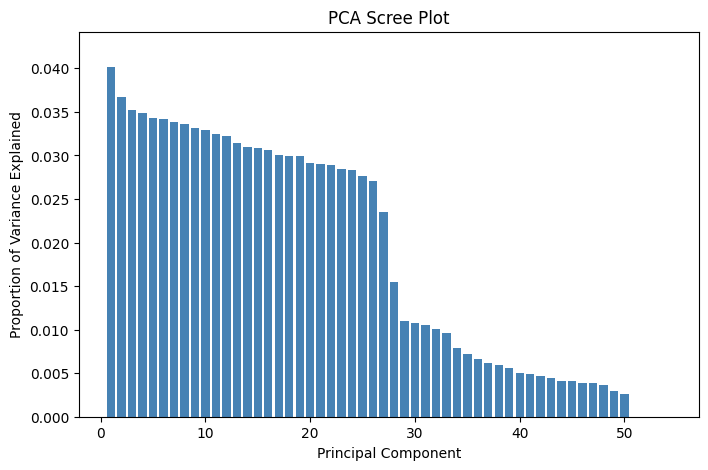

In [14]:
def plot_pca_scree(pca_or_tuple, filename="pca_scree_plot.jpeg"):
    # Accept (pca, scores_df) or just pca
    pca = pca_or_tuple[0] if isinstance(pca_or_tuple, tuple) else pca_or_tuple

    var_explained = getattr(pca, "explained_variance_ratio_", None)
    if var_explained is None:
        raise ValueError("Expected a fitted sklearn PCA object; got something else.")

    scree_data = pd.DataFrame({
        "PC": np.arange(1, len(var_explained) + 1),
        "Variance": var_explained
    })

    plt.figure(figsize=(8, 5))
    plt.bar(scree_data["PC"], scree_data["Variance"], color="steelblue")
    plt.xlabel("Principal Component")
    plt.ylabel("Proportion of Variance Explained")
    plt.title("PCA Scree Plot")
    plt.ylim(0, var_explained.max() * 1.1)  # dynamic max

    # Save plot
    out_path = os.path.join(OUTDIR, filename)
    plt.savefig(out_path, format="jpeg", dpi=300, bbox_inches="tight")
    print(f"Scree plot saved to: {out_path}")

    plt.show()

# Example usage
plot_pca_scree(pca_result)

Generating the plot for Cummulative Explained Variance by PCs

PEV table saved to: ../All Reports/3. PCA and Clustering Reports/pca_variance.csv
   PC       PEV  Cumulative
0   1  0.040180    0.040180
1   2  0.036713    0.076892
2   3  0.035228    0.112121
3   4  0.034810    0.146931
4   5  0.034292    0.181223
5   6  0.034137    0.215361
6   7  0.033796    0.249157
7   8  0.033552    0.282709
8   9  0.033113    0.315821
9  10  0.032897    0.348718
Cumulative variance plot saved to: ../All Reports/3. PCA and Clustering Reports/pca_cumulative_variance.jpeg


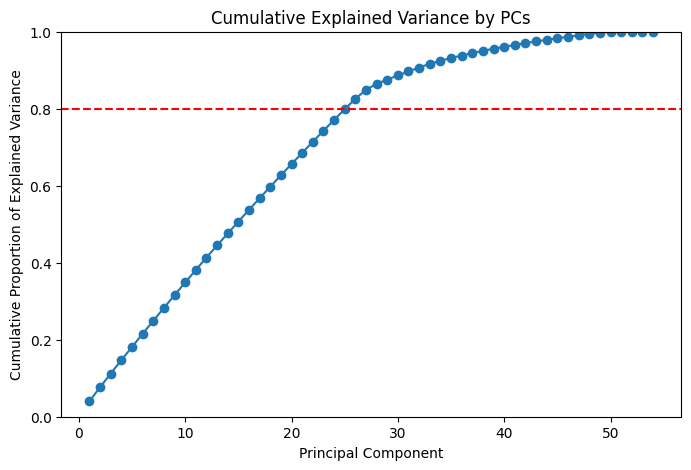

PCA scores saved to: ../All Reports/3. PCA and Clustering Reports/pca_scores.csv


In [15]:
def run_pca_analysis(df, target_col, exclude_cols=None, threshold=0.80):
    if exclude_cols is None:
        exclude_cols = []
    cols_to_exclude = [target_col, *exclude_cols]

    # Keep only numeric columns after exclusion
    X = (df.drop(columns=cols_to_exclude, errors="ignore")
           .select_dtypes(include=["number"]))

    # Remove infinite/NaN values
    X_clean = X.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

    # Fit PCA
    pca = PCA()
    scores = pca.fit_transform(X_clean)

    # Explained variance
    pev = pca.explained_variance_ratio_
    cum = np.cumsum(pev)
    pev_df = pd.DataFrame({
        "PC": np.arange(1, len(pev) + 1),
        "PEV": pev,
        "Cumulative": cum
    })

    # Save CSV for variance table
    pev_csv_path = os.path.join(OUTDIR, "pca_variance.csv")
    pev_df.to_csv(pev_csv_path, index=False)
    print(f"PEV table saved to: {pev_csv_path}")
    print(pev_df.head(10))

    # Plot cumulative variance
    plt.figure(figsize=(8, 5))
    plt.plot(np.arange(1, len(cum) + 1), cum, marker="o")
    plt.axhline(y=threshold, linestyle="--", color="red")
    plt.ylim(0, 1)
    plt.xlabel("Principal Component")
    plt.ylabel("Cumulative Proportion of Explained Variance")
    plt.title("Cumulative Explained Variance by PCs")

    # Save JPEG
    plot_path = os.path.join(OUTDIR, "pca_cumulative_variance.jpeg")
    plt.savefig(plot_path, format="jpeg", dpi=300, bbox_inches="tight")
    print(f"Cumulative variance plot saved to: {plot_path}")
    plt.show()

    # Save PCA scores
    scores_df = pd.DataFrame(scores, index=X_clean.index,
                             columns=[f"PC{i+1}" for i in range(scores.shape[1])])
    scores_csv_path = os.path.join(OUTDIR, "pca_scores.csv")
    scores_df.to_csv(scores_csv_path)
    print(f"PCA scores saved to: {scores_csv_path}")

    return pca, scores_df

# Example
pca_result, pca_scores = run_pca_analysis(
    df_scaled,
    target_col=TARGET_VARIABLE,
    exclude_cols=EXCLUDE_COLUMNS
)

Saved: ../All Reports/3. PCA and Clustering Reports/kmeans_silhouette_pca.csv
Saved: ../All Reports/3. PCA and Clustering Reports/kmeans_best_k_pca.csv
Saved: ../All Reports/3. PCA and Clustering Reports/kmeans_silhouette_bestk_pca.jpeg


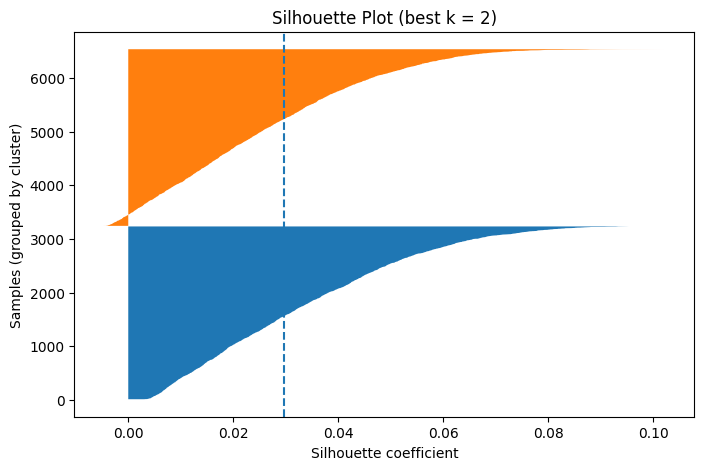

   k       ASW
0  2  0.029716
1  3  0.024974
2  4  0.023281
3  5  0.022684
4  6  0.022402
5  7  0.022893
6  8  0.022348
7  9  0.021858
Best k: 2, PCs used: 32


In [16]:
def run_kmeans_on_pca_scores(pca, scores_df, var_threshold=0.90, k_range=range(2, 10), random_state=123):
    # 1) PCs to reach threshold
    pev = pca.explained_variance_ratio_
    cum = np.cumsum(pev)
    n_pcs = int(np.argmax(cum >= var_threshold)) + 1
    X = scores_df.iloc[:, :n_pcs].to_numpy()

    # 2) Silhouette across k
    sil_widths, kmeans_results = [], {}
    for k in k_range:
        km = KMeans(n_clusters=k, n_init="auto", random_state=random_state)
        labels = km.fit_predict(X)
        asw = silhouette_score(X, labels)
        sil_widths.append(asw)
        kmeans_results[f"k{k}"] = {"model": km, "labels": labels, "ASW": asw}

    # 3) Best k
    sil_df = pd.DataFrame({"k": list(k_range), "ASW": sil_widths})
    best_k = int(sil_df.loc[sil_df["ASW"].idxmax(), "k"])
    best_model = kmeans_results[f"k{best_k}"]["model"]
    best_labels = kmeans_results[f"k{best_k}"]["labels"]

    # --- Save CSVs ---
    sil_csv = os.path.join(OUTDIR, "kmeans_silhouette_pca.csv")
    sil_df.to_csv(sil_csv, index=False)
    best_csv = os.path.join(OUTDIR, "kmeans_best_k_pca.csv")
    pd.DataFrame([{"best_k": best_k, "best_ASW": sil_df["ASW"].max(), "PCs_used": n_pcs}]).to_csv(best_csv, index=False)
    print(f"Saved: {sil_csv}\nSaved: {best_csv}")

    # 4) Plot & save silhouette for best k
    s_vals = silhouette_samples(X, best_labels)
    y_lower = 10
    plt.figure(figsize=(8, 5))
    for i in range(best_k):
        s_i = np.sort(s_vals[best_labels == i])
        y_upper = y_lower + s_i.size
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, s_i)
        y_lower = y_upper + 10
    plt.axvline(s_vals.mean(), linestyle="--")
    plt.xlabel("Silhouette coefficient")
    plt.ylabel("Samples (grouped by cluster)")
    plt.title(f"Silhouette Plot (best k = {best_k})")

    sil_jpg = os.path.join(OUTDIR, "kmeans_silhouette_bestk_pca.jpeg")
    plt.savefig(sil_jpg, format="jpeg", dpi=300, bbox_inches="tight")
    print(f"Saved: {sil_jpg}")
    plt.show()

    return {
        "pca_result": pca,
        "pca_scores": scores_df.iloc[:, :n_pcs],
        "kmeans_results": kmeans_results,
        "sil_df": sil_df,
        "best_k": best_k,
        "best_model": best_model
    }

# ==== Example usage ====
out = run_kmeans_on_pca_scores(
    pca=pca_result,
    scores_df=pca_scores,
    var_threshold=0.90,
    k_range=range(2, 10)
)

print(out["sil_df"])
print(f"Best k: {out['best_k']}, PCs used: {out['pca_scores'].shape[1]}")


Best k by average silhouette: 2
Cluster plot saved to: ../All Reports/3. PCA and Clustering Reports/kmeans_clusters_k2_pca.jpeg


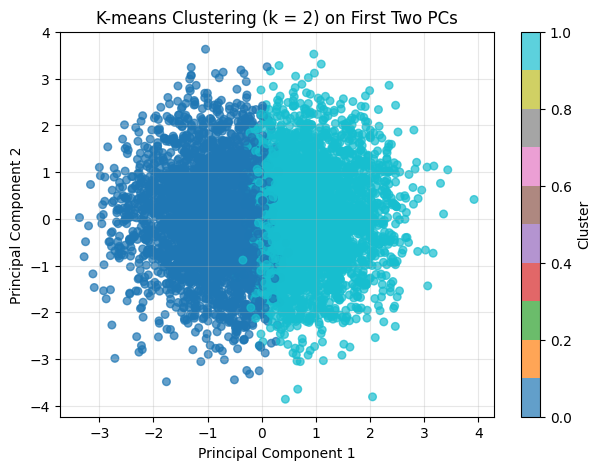

In [17]:
def plot_kmeans_clusters(pca_scores, sil_df, kmeans_results):
    """
    Plot K-means clustering results on the first two principal components
    and save the plot to OUTDIR as JPEG.

    Parameters:
    - pca_scores: DataFrame of PCA scores (from run_kmeans_on_pca_scores output)
    - sil_df: DataFrame with columns ['k', 'ASW'] from silhouette analysis
    - kmeans_results: dict of fitted models and labels from run_kmeans_on_pca_scores

    Returns:
    - plot_df: DataFrame with PC1, PC2, and cluster assignment
    - best_k: Best number of clusters by silhouette score
    """
    # 1) Best k
    best_k = int(sil_df.loc[sil_df["ASW"].idxmax(), "k"])
    print(f"Best k by average silhouette: {best_k}")

    # 2) Labels
    best_labels = kmeans_results[f"k{best_k}"]["labels"]

    # 3) DataFrame for plotting
    plot_df = pd.DataFrame({
        "PC1": pca_scores.iloc[:, 0],
        "PC2": pca_scores.iloc[:, 1],
        "cluster": best_labels.astype(str)
    })

    # 4) Plot
    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(
        plot_df["PC1"], plot_df["PC2"],
        c=plot_df["cluster"].astype(int), cmap="tab10",
        alpha=0.7, s=30
    )
    plt.title(f"K-means Clustering (k = {best_k}) on First Two PCs")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.colorbar(scatter, label="Cluster")
    plt.grid(True, alpha=0.3)

    # Save JPEG
    out_path = os.path.join(OUTDIR, f"kmeans_clusters_k{best_k}_pca.jpeg")
    plt.savefig(out_path, format="jpeg", dpi=300, bbox_inches="tight")
    print(f"Cluster plot saved to: {out_path}")

    plt.show()

    return plot_df, best_k

# ==== Example usage ====
plot_df, best_k = plot_kmeans_clusters(
    pca_scores=out["pca_scores"],
    sil_df=out["sil_df"],
    kmeans_results=out["kmeans_results"]
)

K-Means without PCA

    k       ASW
0   2  0.026931
1   3  0.022610
2   4  0.021015
3   5  0.020601
4   6  0.020033
5   7  0.020120
6   8  0.019957
7   9  0.020376
8  10  0.020417
Best k by average silhouette width: 2
Saved: ../All Reports/3. PCA and Clustering Reports/kmeans_silhouette_no_pca.csv
Saved: ../All Reports/3. PCA and Clustering Reports/kmeans_silhouette_vs_k_no_pca.jpeg


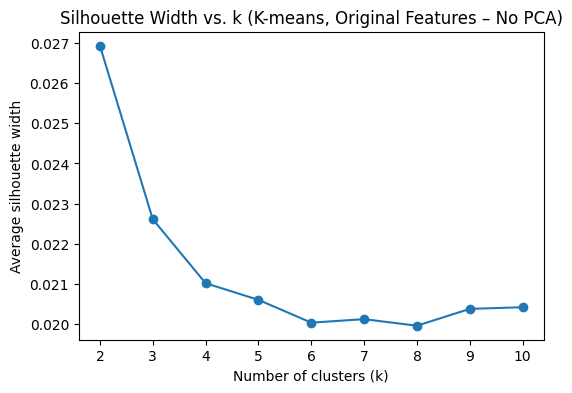

Saved: ../All Reports/3. PCA and Clustering Reports/kmeans_silhouette_bestk_no_pca.jpeg


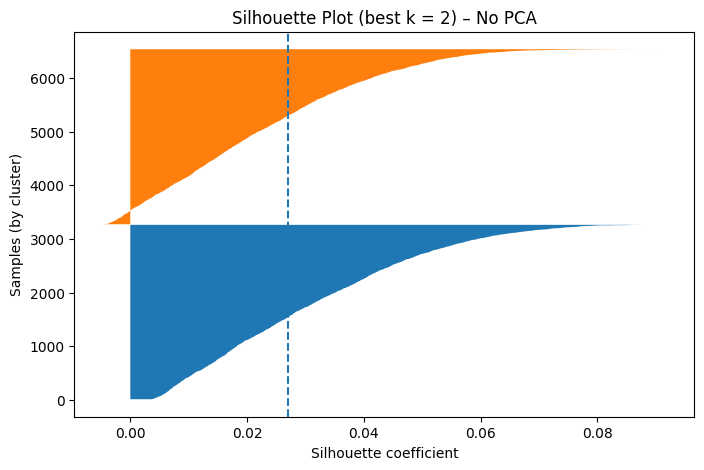

Saved: ../All Reports/3. PCA and Clustering Reports/kmeans_clusters_pca2d_no_pca.jpeg


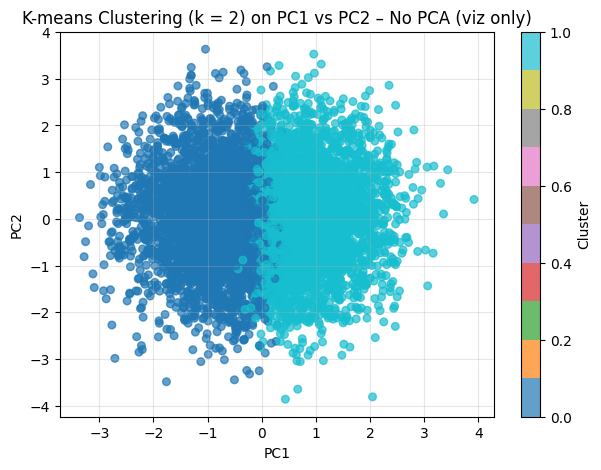

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

def run_kmeans_no_pca(df, target_col, exclude_cols=None, k_range=range(2, 11), random_state=123):
    """
    K-means on the original ALREADY-SCALED features (no PCA for fitting).
    Saves:
      - Silhouette Width vs k plot → OUTDIR/kmeans_silhouette_vs_k_no_pca.jpeg
      - Silhouette Plot (best k)   → OUTDIR/kmeans_silhouette_bestk_no_pca.jpeg
      - Cluster scatter in 2D PCA  → OUTDIR/kmeans_clusters_pca2d_no_pca.jpeg
      - Silhouette scores table    → OUTDIR/kmeans_silhouette_no_pca.csv
    """
    if exclude_cols is None:
        exclude_cols = []
    X = (df.drop(columns=[target_col, *exclude_cols], errors="ignore")
           .select_dtypes(include=[np.number]))
    X_clean = X.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

    # --- Search k by silhouette ---
    sil_scores, models, labels_map = [], {}, {}
    for k in k_range:
        km = KMeans(n_clusters=k, n_init="auto", random_state=random_state)
        lbl = km.fit_predict(X_clean)
        sil = silhouette_score(X_clean, lbl)
        sil_scores.append(sil)
        models[k] = km
        labels_map[k] = lbl

    sil_df = pd.DataFrame({"k": list(k_range), "ASW": sil_scores})
    best_k = int(sil_df.loc[sil_df["ASW"].idxmax(), "k"])
    best_model = models[best_k]
    best_labels = labels_map[best_k]
    print(sil_df)
    print(f"Best k by average silhouette width: {best_k}")

    # --- Save silhouette table (CSV) ---
    sil_csv = os.path.join(OUTDIR, "kmeans_silhouette_no_pca.csv")
    sil_df.to_csv(sil_csv, index=False)
    print(f"Saved: {sil_csv}")

    # --- Plot 1: ASW vs k (save JPEG) ---
    plt.figure(figsize=(6, 4))
    plt.plot(sil_df["k"], sil_df["ASW"], marker="o")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Average silhouette width")
    plt.title("Silhouette Width vs. k (K-means, Original Features – No PCA)")
    asw_vs_k_jpg = os.path.join(OUTDIR, "kmeans_silhouette_vs_k_no_pca.jpeg")
    plt.savefig(asw_vs_k_jpg, format="jpeg", dpi=300, bbox_inches="tight")
    print(f"Saved: {asw_vs_k_jpg}")
    plt.show()

    # --- Plot 2: Silhouette for best k (save JPEG) ---
    s_vals = silhouette_samples(X_clean, best_labels)
    y_lower = 10
    plt.figure(figsize=(8, 5))
    for i in range(best_k):
        s_i = np.sort(s_vals[best_labels == i])
        y_upper = y_lower + len(s_i)
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, s_i)
        y_lower = y_upper + 10
    plt.axvline(s_vals.mean(), linestyle="--")
    plt.xlabel("Silhouette coefficient")
    plt.ylabel("Samples (by cluster)")
    plt.title(f"Silhouette Plot (best k = {best_k}) – No PCA")
    sil_best_jpg = os.path.join(OUTDIR, "kmeans_silhouette_bestk_no_pca.jpeg")
    plt.savefig(sil_best_jpg, format="jpeg", dpi=300, bbox_inches="tight")
    print(f"Saved: {sil_best_jpg}")
    plt.show()

    # --- Plot 3: Cluster scatter in PCA 2D (viz only; save JPEG) ---
    pca_viz = PCA(n_components=2)  # visualization only; data already standardized
    pcs_2d = pca_viz.fit_transform(X_clean)
    plot_df = pd.DataFrame({"PC1": pcs_2d[:, 0], "PC2": pcs_2d[:, 1], "cluster": best_labels.astype(str)})

    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(plot_df["PC1"], plot_df["PC2"],
                          c=plot_df["cluster"].astype(int), cmap="tab10", alpha=0.7, s=30)
    plt.title(f"K-means Clustering (k = {best_k}) on PC1 vs PC2 – No PCA (viz only)")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.colorbar(scatter, label="Cluster")
    plt.grid(True, alpha=0.3)
    clusters_jpg = os.path.join(OUTDIR, "kmeans_clusters_pca2d_no_pca.jpeg")
    plt.savefig(clusters_jpg, format="jpeg", dpi=300, bbox_inches="tight")
    print(f"Saved: {clusters_jpg}")
    plt.show()

    return {
        "X_used": X_clean,
        "sil_df": sil_df,
        "best_k": best_k,
        "best_model": best_model,
        "labels": best_labels,
        "plot_df_pca2d": plot_df,
        "pca_viz": pca_viz
    }

# ==== Example usage ====
results_no_pca = run_kmeans_no_pca(
    df=df_scaled,
    target_col=TARGET_VARIABLE,
    exclude_cols=EXCLUDE_COLUMNS
)

Hierarchical Clustering with PCA results

   k       ASW
0  2  0.008847
1  3  0.003267
2  4 -0.000117
3  5 -0.003483
4  6 -0.003356
5  7 -0.004913
6  8 -0.005153
7  9 -0.005670
Best k by average silhouette (hierarchical): 2 | ASW = 0.009 | PCs used = 32
Saved: ../All Reports/3. PCA and Clustering Reports/hierarchical_silhouette_scores_pca.csv
Saved: ../All Reports/3. PCA and Clustering Reports/hierarchical_silhouette_bestk_pca.jpeg


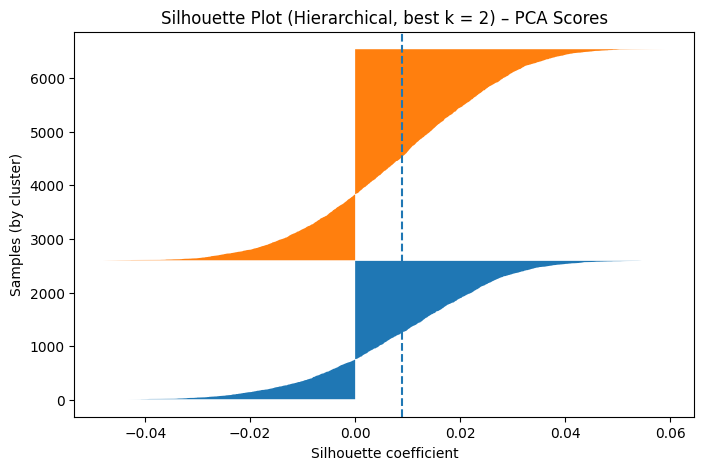

Saved: ../All Reports/3. PCA and Clustering Reports/hierarchical_dendrogram_pca.jpeg


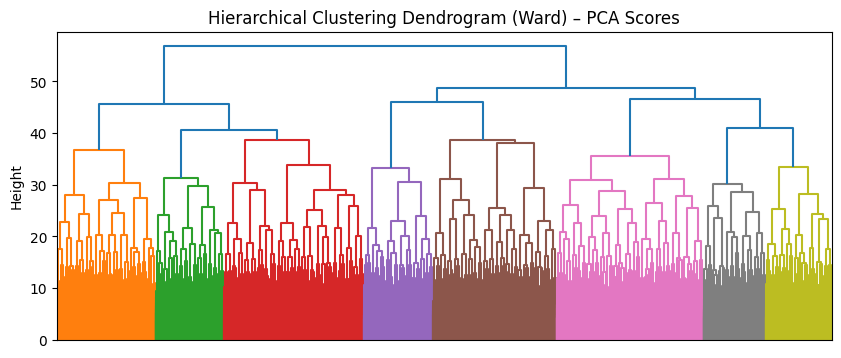

Saved: ../All Reports/3. PCA and Clustering Reports/hierarchical_clusters_pca.jpeg


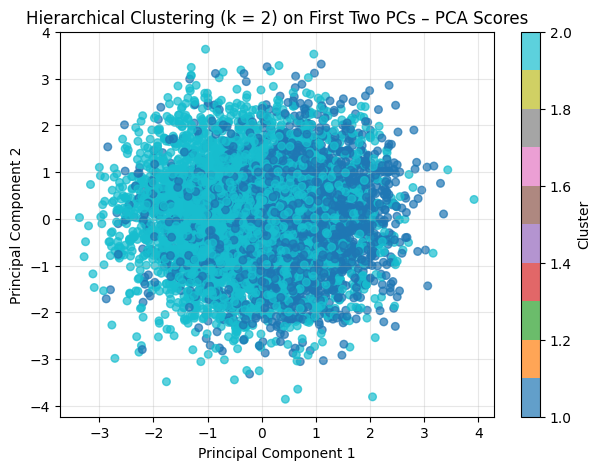

In [19]:
def run_hierarchical_on_pca_scores(pca, scores_df, var_threshold=0.90, k_range=range(2,10), linkage_method="ward"):
    """
    Runs hierarchical clustering on PCA scores and saves:
      - Silhouette Plot (best k)       → JPEG
      - Dendrogram                     → JPEG
      - Cluster scatter plot (PC1, PC2)→ JPEG
      - Silhouette scores table        → CSV
    """
    # 1) PCs to reach variance threshold
    pev = pca.explained_variance_ratio_
    n_pcs = int(np.argmax(np.cumsum(pev) >= var_threshold)) + 1
    X = scores_df.iloc[:, :n_pcs].to_numpy()

    # 2) Linkage
    Z = linkage(X, method=linkage_method, metric="euclidean")

    # 3) Silhouette search
    rows, labels_map = [], {}
    for k in k_range:
        lbl = fcluster(Z, t=k, criterion="maxclust")
        asw = silhouette_score(X, lbl)
        rows.append((k, asw))
        labels_map[k] = lbl

    sil_df = pd.DataFrame(rows, columns=["k", "ASW"])
    best_k = int(sil_df.loc[sil_df["ASW"].idxmax(), "k"])
    best_labels = labels_map[best_k]

    print(sil_df)
    print(f"Best k by average silhouette (hierarchical): {best_k} | "
          f"ASW = {sil_df['ASW'].max():.3f} | PCs used = {n_pcs}")

    # Save silhouette scores table
    sil_csv = os.path.join(OUTDIR, "hierarchical_silhouette_scores_pca.csv")
    sil_df.to_csv(sil_csv, index=False)
    print(f"Saved: {sil_csv}")

    # 4) Silhouette Plot for best k
    s_vals = silhouette_samples(X, best_labels)
    y_lower = 10
    plt.figure(figsize=(8,5))
    for i in range(1, best_k + 1):
        s_i = np.sort(s_vals[best_labels == i])
        y_upper = y_lower + len(s_i)
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, s_i)
        y_lower = y_upper + 10
    plt.axvline(s_vals.mean(), linestyle="--")
    plt.xlabel("Silhouette coefficient")
    plt.ylabel("Samples (by cluster)")
    plt.title(f"Silhouette Plot (Hierarchical, best k = {best_k}) – PCA Scores")
    sil_jpg = os.path.join(OUTDIR, "hierarchical_silhouette_bestk_pca.jpeg")
    plt.savefig(sil_jpg, format="jpeg", dpi=300, bbox_inches="tight")
    print(f"Saved: {sil_jpg}")
    plt.show()

    # 5) Dendrogram
    plt.figure(figsize=(10,4))
    dendrogram(Z, no_labels=True, color_threshold=None)
    plt.title("Hierarchical Clustering Dendrogram (Ward) – PCA Scores")
    plt.ylabel("Height")
    dendro_jpg = os.path.join(OUTDIR, "hierarchical_dendrogram_pca.jpeg")
    plt.savefig(dendro_jpg, format="jpeg", dpi=300, bbox_inches="tight")
    print(f"Saved: {dendro_jpg}")
    plt.show()

    # 6) Scatter plot on first two PCs
    plot_df = pd.DataFrame({
        "PC1": scores_df.iloc[:, 0],
        "PC2": scores_df.iloc[:, 1],
        "cluster": best_labels.astype(str)
    }, index=scores_df.index)

    plt.figure(figsize=(7,5))
    scatter = plt.scatter(plot_df["PC1"], plot_df["PC2"],
                          c=plot_df["cluster"].astype(int), cmap="tab10", alpha=0.7, s=30)
    plt.title(f"Hierarchical Clustering (k = {best_k}) on First Two PCs – PCA Scores")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.colorbar(scatter, label="Cluster")
    plt.grid(True, alpha=0.3)
    scatter_jpg = os.path.join(OUTDIR, "hierarchical_clusters_pca.jpeg")
    plt.savefig(scatter_jpg, format="jpeg", dpi=300, bbox_inches="tight")
    print(f"Saved: {scatter_jpg}")
    plt.show()

    return {
        "n_pcs": n_pcs,
        "linkage_matrix": Z,
        "sil_df": sil_df,
        "best_k": best_k,
        "labels": best_labels,
        "plot_df": plot_df
    }

# ==== Example usage ====
hc_out = run_hierarchical_on_pca_scores(
    pca=pca_result,
    scores_df=pca_scores,
    var_threshold=0.90,
    k_range=range(2,10),
    linkage_method="ward"
)

Hierarchical Clustering without PCA

   k       ASW
0  2  0.006759
1  3  0.000619
2  4 -0.000147
3  5 -0.001819
4  6 -0.003065
5  7 -0.003865
6  8 -0.003387
7  9 -0.004517
Best k by average silhouette (hierarchical): 2 | ASW = 0.007
Saved: ../All Reports/3. PCA and Clustering Reports/hierarchical_silhouette_no_pca.csv
Saved: ../All Reports/3. PCA and Clustering Reports/hierarchical_silhouette_vs_k_no_pca.jpeg


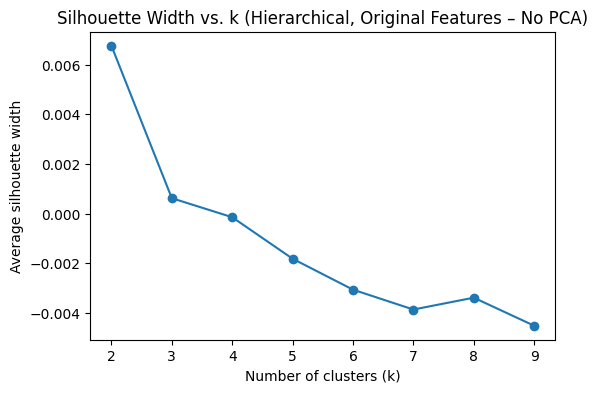

Saved: ../All Reports/3. PCA and Clustering Reports/hierarchical_silhouette_bestk_no_pca.jpeg


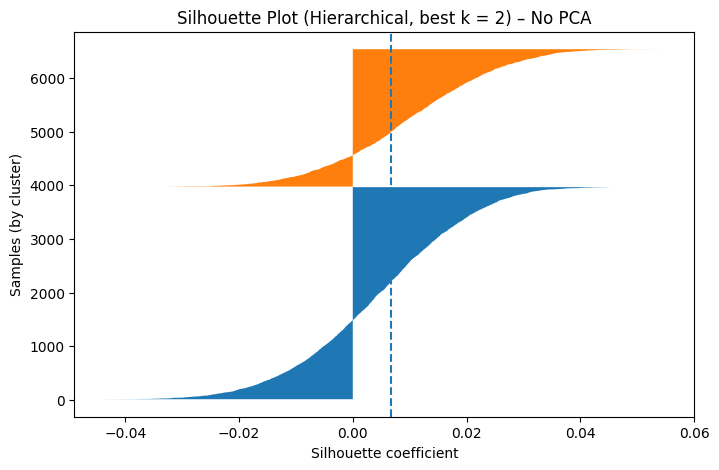

Saved: ../All Reports/3. PCA and Clustering Reports/hierarchical_clusters_pca2d_no_pca.jpeg


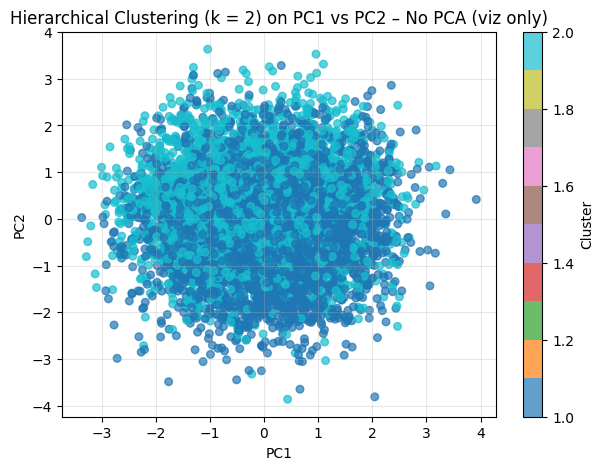

In [20]:
def run_hierarchical_no_pca(df, target_col, exclude_cols=None, k_range=range(2, 10), linkage_method="ward"):
    """
    Hierarchical clustering on the original ALREADY-SCALED features (no PCA for fitting).
    Saves:
      - Silhouette Width vs k plot  → OUTDIR/hierarchical_silhouette_vs_k_no_pca.jpeg
      - Silhouette Plot (best k)    → OUTDIR/hierarchical_silhouette_bestk_no_pca.jpeg
      - Cluster scatter in PCA 2D   → OUTDIR/hierarchical_clusters_pca2d_no_pca.jpeg
      - Silhouette scores table     → OUTDIR/hierarchical_silhouette_no_pca.csv
    """
    if exclude_cols is None:
        exclude_cols = []
    # Use numeric features only; drop target/exclusions (data already standardized upstream)
    X = (df.drop(columns=[target_col, *exclude_cols], errors="ignore")
           .select_dtypes(include=[np.number]))
    X = X.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

    # Linkage on original scaled features (Ward + Euclidean)
    Z = linkage(X, method=linkage_method, metric="euclidean")

    # Try k in range and record ASW
    rows, labels_map = [], {}
    for k in k_range:
        lbl = fcluster(Z, t=k, criterion="maxclust")
        asw = silhouette_score(X, lbl)
        rows.append((k, asw))
        labels_map[k] = lbl
    sil_df = pd.DataFrame(rows, columns=["k", "ASW"])
    best_k = int(sil_df.loc[sil_df["ASW"].idxmax(), "k"])
    best_labels = labels_map[best_k]
    print(sil_df)
    print(f"Best k by average silhouette (hierarchical): {best_k} | ASW = {sil_df['ASW'].max():.3f}")

    # Save silhouette table (CSV)
    sil_csv = os.path.join(OUTDIR, "hierarchical_silhouette_no_pca.csv")
    sil_df.to_csv(sil_csv, index=False)
    print(f"Saved: {sil_csv}")

    # Plot 1: ASW vs k → JPEG
    plt.figure(figsize=(6,4))
    plt.plot(sil_df["k"], sil_df["ASW"], marker="o")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Average silhouette width")
    plt.title("Silhouette Width vs. k (Hierarchical, Original Features – No PCA)")
    asw_vs_k_jpg = os.path.join(OUTDIR, "hierarchical_silhouette_vs_k_no_pca.jpeg")
    plt.savefig(asw_vs_k_jpg, format="jpeg", dpi=300, bbox_inches="tight")
    print(f"Saved: {asw_vs_k_jpg}")
    plt.show()

    # Plot 2: Silhouette for best k → JPEG
    s_vals = silhouette_samples(X, best_labels)
    y_lower = 10
    plt.figure(figsize=(8,5))
    for i in range(1, best_k + 1):
        s_i = np.sort(s_vals[best_labels == i])
        y_upper = y_lower + len(s_i)
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, s_i)
        y_lower = y_upper + 10
    plt.axvline(s_vals.mean(), linestyle="--")
    plt.xlabel("Silhouette coefficient"); plt.ylabel("Samples (by cluster)")
    plt.title(f"Silhouette Plot (Hierarchical, best k = {best_k}) – No PCA")
    sil_best_jpg = os.path.join(OUTDIR, "hierarchical_silhouette_bestk_no_pca.jpeg")
    plt.savefig(sil_best_jpg, format="jpeg", dpi=300, bbox_inches="tight")
    print(f"Saved: {sil_best_jpg}")
    plt.show()

    # Plot 3: Cluster scatter in PCA 2D (viz only) → JPEG
    pca_viz = PCA(n_components=2)  # visualization only; clustering done on original scaled features
    pcs_2d = pca_viz.fit_transform(X)
    plot_df = pd.DataFrame({"PC1": pcs_2d[:,0], "PC2": pcs_2d[:,1], "cluster": best_labels.astype(str)}, index=X.index)

    plt.figure(figsize=(7,5))
    scatter = plt.scatter(plot_df["PC1"], plot_df["PC2"],
                          c=plot_df["cluster"].astype(int), cmap="tab10", alpha=0.7, s=30)
    plt.title(f"Hierarchical Clustering (k = {best_k}) on PC1 vs PC2 – No PCA (viz only)")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.colorbar(scatter, label="Cluster"); plt.grid(True, alpha=0.3)
    clusters_jpg = os.path.join(OUTDIR, "hierarchical_clusters_pca2d_no_pca.jpeg")
    plt.savefig(clusters_jpg, format="jpeg", dpi=300, bbox_inches="tight")
    print(f"Saved: {clusters_jpg}")
    plt.show()

    return {
        "linkage_matrix": Z,
        "sil_df": sil_df,
        "best_k": best_k,
        "labels": best_labels,
        "plot_df": plot_df,
        "pca_viz": pca_viz
    }

# ==== Example usage ====
hc_no_pca_out = run_hierarchical_no_pca(
    df=df_scaled,                # already Z-scored except binaries
    target_col=TARGET_VARIABLE,  # e.g., "Alzheimer.s.Diagnosis"
    exclude_cols=EXCLUDE_COLUMNS,
    k_range=range(2, 10)
)


HDBSCAN clustering

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/pytho

   min_cluster_size       ASW  n_clusters  noise_frac
0                 2 -0.040999           5    0.278221
1                 3 -0.041194           4    0.635276
2                 4  0.030706           2    0.765491
3                 5 -0.014412           3    0.896012
4                 6  0.007091           3    0.977147
Best config: min_cluster_size=4 | ASW=0.031 | PCs used=32


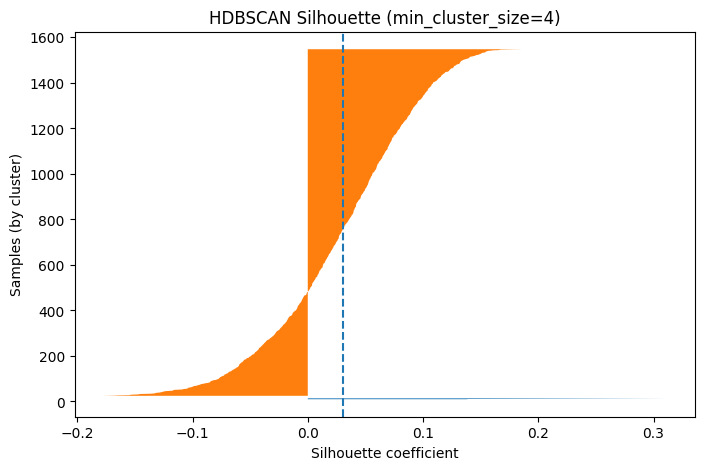

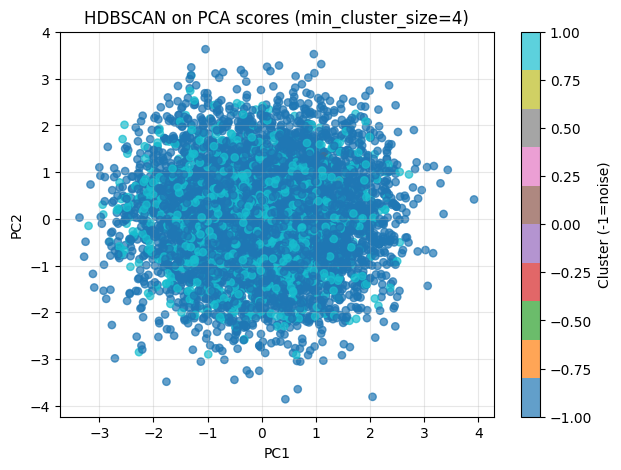

In [21]:
def run_hdbscan_on_pca_scores(pca, scores_df, var_threshold=0.90,
                              min_cluster_size_list=(10, 8, 6, 4, 2),
                              min_samples=None, metric="euclidean", random_state=123):
    # Keep PCs until threshold (no extra scaling here)
    pev = pca.explained_variance_ratio_
    n_pcs = int(np.argmax(np.cumsum(pev) >= var_threshold)) + 1
    X = scores_df.iloc[:, :n_pcs].to_numpy()

    results = []
    models = {}
    for mcs in min_cluster_size_list:
        clusterer = hdbscan.HDBSCAN(min_cluster_size=mcs,
                                    min_samples=min_samples,
                                    metric=metric,
                                    prediction_data=True)
        labels = clusterer.fit_predict(X)
        # Silhouette on non-noise points only
        mask = labels >= 0
        n_clusters = len(np.unique(labels[mask])) if mask.any() else 0
        asw = silhouette_score(X[mask], labels[mask]) if n_clusters >= 2 else np.nan
        noise_frac = 1.0 - mask.mean()
        results.append((mcs, asw, n_clusters, noise_frac))
        models[mcs] = (clusterer, labels)

    sil_df = pd.DataFrame(results, columns=["min_cluster_size","ASW","n_clusters","noise_frac"])
    # Pick best ASW with at least 2 clusters
    valid = sil_df.dropna().query("n_clusters >= 2")
    if valid.empty:
        best_mcs = max(min_cluster_size_list)  # fallback
    else:
        best_mcs = int(valid.loc[valid["ASW"].idxmax(), "min_cluster_size"])
    best_model, best_labels = models[best_mcs]

    print(sil_df)
    if not valid.empty:
        print(f"Best config: min_cluster_size={best_mcs} | ASW={valid.loc[valid['min_cluster_size']==best_mcs,'ASW'].item():.3f} | PCs used={n_pcs}")
    else:
        print(f"No valid silhouette (>=2 clusters). Returning model with min_cluster_size={best_mcs}.")

    # Silhouette plot (non-noise only)
    mask = best_labels >= 0
    if mask.sum() >= 2 and len(np.unique(best_labels[mask])) >= 2:
        s_vals = silhouette_samples(X[mask], best_labels[mask])
        y_lower = 10
        plt.figure(figsize=(8,5))
        for cid in np.unique(best_labels[mask]):
            s_i = np.sort(s_vals[best_labels[mask]==cid])
            y_upper = y_lower + len(s_i)
            plt.fill_betweenx(np.arange(y_lower, y_upper), 0, s_i)
            y_lower = y_upper + 10
        plt.axvline(s_vals.mean(), linestyle="--")
        plt.xlabel("Silhouette coefficient"); plt.ylabel("Samples (by cluster)")
        plt.title(f"HDBSCAN Silhouette (min_cluster_size={best_mcs})")
        plt.show()

    # PC1 vs PC2 scatter (directly from scores_df)
    plot_df = pd.DataFrame({
        "PC1": scores_df.iloc[:, 0],
        "PC2": scores_df.iloc[:, 1],
        "cluster": np.where(best_labels>=0, best_labels, -1).astype(int)
    }, index=scores_df.index)

    plt.figure(figsize=(7,5))
    colors = np.where(plot_df["cluster"]==-1, "lightgray", plot_df["cluster"])
    sc = plt.scatter(plot_df["PC1"], plot_df["PC2"],
                     c=np.where(plot_df["cluster"]==-1, -1, plot_df["cluster"]),
                     cmap="tab10", alpha=0.7, s=28)
    plt.title(f"HDBSCAN on PCA scores (min_cluster_size={best_mcs})")
    plt.xlabel("PC1"); plt.ylabel("PC2"); plt.grid(True, alpha=0.3)
    plt.colorbar(sc, label="Cluster (-1=noise)")
    plt.show()

    return {
        "n_pcs": n_pcs,
        "sil_df": sil_df,
        "best_min_cluster_size": best_mcs,
        "model": best_model,
        "labels": best_labels,
    }

hdb_pca_out = run_hdbscan_on_pca_scores(
    pca=pca_result,
    scores_df=pca_scores,
    var_threshold=0.90,
    min_cluster_size_list=(2, 3, 4, 5, 6)
)


HDBSCAN clustering without PCA

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/pytho

   min_cluster_size       ASW  n_clusters  noise_frac
0                 2 -0.026369           4    0.247086
1                 3  0.030112           2    0.550153
2                 4 -0.022502           4    0.880982
3                 5  0.013265           2    0.928681
4                 6  0.000670           3    0.967178
Best config: min_cluster_size=3 | ASW=0.030


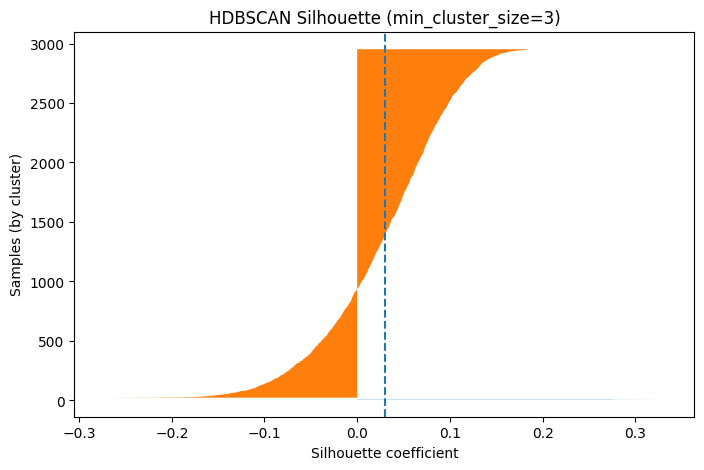

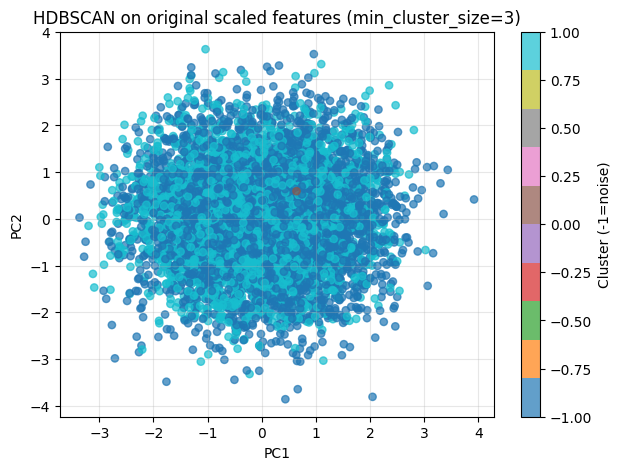

In [22]:
def run_hdbscan_no_pca(df, target_col, exclude_cols=None,
                       min_cluster_size_list=(10, 20, 30, 40, 50),
                       min_samples=None, metric="euclidean", random_state=123):
    # Use already-scaled numeric data; drop target/exclusions
    if exclude_cols is None:
        exclude_cols = []
    X = (df.drop(columns=[target_col, *exclude_cols], errors="ignore")
           .select_dtypes(include=[np.number]))
    X = X.replace([np.inf, -np.inf], np.nan).dropna(axis=0).to_numpy()

    results = []
    models = {}
    for mcs in min_cluster_size_list:
        clusterer = hdbscan.HDBSCAN(min_cluster_size=mcs,
                                    min_samples=min_samples,
                                    metric=metric,
                                    prediction_data=True)
        labels = clusterer.fit_predict(X)
        mask = labels >= 0
        n_clusters = len(np.unique(labels[mask])) if mask.any() else 0
        asw = silhouette_score(X[mask], labels[mask]) if n_clusters >= 2 else np.nan
        noise_frac = 1.0 - mask.mean()
        results.append((mcs, asw, n_clusters, noise_frac))
        models[mcs] = (clusterer, labels)

    sil_df = pd.DataFrame(results, columns=["min_cluster_size","ASW","n_clusters","noise_frac"])
    valid = sil_df.dropna().query("n_clusters >= 2")
    if valid.empty:
        best_mcs = max(min_cluster_size_list)
    else:
        best_mcs = int(valid.loc[valid["ASW"].idxmax(), "min_cluster_size"])
    best_model, best_labels = models[best_mcs]

    print(sil_df)
    if not valid.empty:
        print(f"Best config: min_cluster_size={best_mcs} | ASW={valid.loc[valid['min_cluster_size']==best_mcs,'ASW'].item():.3f}")
    else:
        print(f"No valid silhouette (>=2 clusters). Returning model with min_cluster_size={best_mcs}.")

    # Silhouette plot (non-noise only)
    mask = best_labels >= 0
    if mask.sum() >= 2 and len(np.unique(best_labels[mask])) >= 2:
        s_vals = silhouette_samples(X[mask], best_labels[mask])
        y_lower = 10
        plt.figure(figsize=(8,5))
        for cid in np.unique(best_labels[mask]):
            s_i = np.sort(s_vals[best_labels[mask]==cid])
            y_upper = y_lower + len(s_i)
            plt.fill_betweenx(np.arange(y_lower, y_upper), 0, s_i)
            y_lower = y_upper + 10
        plt.axvline(s_vals.mean(), linestyle="--")
        plt.xlabel("Silhouette coefficient"); plt.ylabel("Samples (by cluster)")
        plt.title(f"HDBSCAN Silhouette (min_cluster_size={best_mcs})")
        plt.show()

    # Viz only: 2D PCA projection of original scaled features
    pca_viz = PCA(n_components=2)
    pcs_2d = pca_viz.fit_transform(X)
    plot_df = pd.DataFrame({"PC1": pcs_2d[:,0], "PC2": pcs_2d[:,1],
                            "cluster": np.where(best_labels>=0, best_labels, -1).astype(int)})

    plt.figure(figsize=(7,5))
    sc = plt.scatter(plot_df["PC1"], plot_df["PC2"],
                     c=np.where(plot_df["cluster"]==-1, -1, plot_df["cluster"]),
                     cmap="tab10", alpha=0.7, s=28)
    plt.title(f"HDBSCAN on original scaled features (min_cluster_size={best_mcs})")
    plt.xlabel("PC1"); plt.ylabel("PC2"); plt.grid(True, alpha=0.3)
    plt.colorbar(sc, label="Cluster (-1=noise)")
    plt.show()

    return {
        "sil_df": sil_df,
        "best_min_cluster_size": best_mcs,
        "model": best_model,
        "labels": best_labels,
        "plot_df": plot_df
    }

hdb_no_pca_out = run_hdbscan_no_pca(
    df=df_scaled,
    target_col=TARGET_VARIABLE,
    exclude_cols=EXCLUDE_COLUMNS,
    min_cluster_size_list=(2,3,4,5,6)
)

Exporting the scaled file for ML and DL Modelling

In [23]:
df_scaled.to_csv("../Datasets/Final_Modelling_Dataset.csv", index=False)